## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Create session
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

### Styling

In [4]:
from matplotlib.colors import ListedColormap

# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : 'Nuläge',
    '70' : '-30 % CH$_{4}$',
    '100' : '$\pm$0 % CH$_{4}$',
    '110' : '+10 % CH$_{4}$'
}

rename_scn = lambda x: x.lower().replace('_','-') if x != 'BL' else ''
rename_scn_h = lambda x: ' ' if x != 'BL' else ''

rename_spbr_swe = {
    'cattle, dairy' : 'Nötkreatur, mjölkras',
    'cattle, beef' : 'Nötkreatur, köttras',
    'sheep' : 'Får',
    'horses' : 'Hästar',
    'horses, cons.' : 'Hästar (naturvård)',
    'poultry' : 'Fåglar',
    'pigs' : 'Grisar'
}

# Sensitivity analysis Scenarios 
sens = []

# Scenario sort
sort = list(
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .xs('100', level='year')
    .sum(axis=1)
    .sort_values()
    .index
)
# Add BL and remove sensitivity analysis scenarios
sort = ['BL'] + [s for s in sort if s not in sens]

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax, ta=1.3, cols=2):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,ta), frameon=False, ncol=cols, fontsize=9, reverse=True)
def _legend_n(ax):  
    ax.legend().set_visible(False)

def _annotate(ax, lab):
    ax.annotate(lab, xy=(-0.2, 1.1), xycoords='axes fraction', fontsize=11, fontweight='bold', ha='right', va='bottom')


def _LSU(x):
    '''Gives livestock units (LSU) per head based on a tuple of (species, breed, animal)
    according to https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Livestock_unit_(LSU)'''
    sp,br,an = x
    if sp == 'cattle':
        if an == 'cows':
            if br == 'dairy':
                return 1
            else:
                return 0.8
        elif an == 'calves':
            return 0.4
        elif an == 'breeding bulls':
            return 1
        else:
            return 0.8
    elif sp == 'sheep':
        return 0.1
    elif sp == 'pigs':
        if an == 'piglets':
            return 0.027
        elif an == 'sows':
            return 0.5
        else:
            return 0.3
    elif sp == 'horses':
        return 0.8
    elif sp == 'poultry':
        if an == 'broilers':
            return 0.007
        else:
            return 0.014
    else:
        return np.nan

def no_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False, labelleft=False)

## Get data

In [5]:
sng = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
    .rename({
        'Semi-natural meadows' : 'Slåtteräng',
        'Semi-natural pastures' : 'Naturbetesmark',
        'Semi-natural pastures, thin soils' : 'Alvarbete etc.',
        'Semi-natural pastures, wooded' : 'Skogsbete'
    }, axis=1)
).sum(axis=1)/1_000_000

sng_max = session.get_attr('r','max_land_use','land_use').loc[('MAX_CUR','100'),'semi-natural grasslands'] / 1_000_000

sng_bl = sng.loc['BL'].iloc[0].sum()



In [6]:
cropland = session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None}).loc[:,'cropland']/1_000
cropland_tot = cropland.T.groupby('region').sum().T

ley = cropland.loc[:,'Ley']
ley_prc = ley / cropland_tot * 100

cereals = cropland.loc[:,['Cereals, spring', 'Cereals, winter']].T.groupby('region').sum().T
cereals_prc = cereals / cropland_tot * 100

In [7]:
scns = [s for s in sort if s not in ['ALL + NAT_HORSES']]

grazing_per_lu = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .rename(rename_years)
    .rename(columns={'cropland':'arable'})
    .loc[(scns,['Nuläge','$\pm$0 % CH$_{4}$']),:]
    .droplevel('year')
    .rename(
        index = rename_scn,
        columns = {'arable':'Åkermark', 'semi-natural grasslands':'Naturbetesmark'}
    )
    .rename({'':'Nuläge'})
    .sort_values(axis=1, by='Nuläge')
)/1_000_000_000

grazing_per_species = (
    session.get_attr('a', 'feed.crop_product_demand', ['crop_prod','species','breed'])
    .loc[:,'grazing']
    .rename(rename_years)
    .loc[(scns,['Nuläge','$\pm$0 % CH$_{4}$']),:]
    .droplevel('year')
    .rename(index = rename_scn,)
    .rename({'':'Nuläge'})
)/1_000_000_000

grazing_per_species.columns = grazing_per_species.columns = pd.MultiIndex.from_tuples(
    [(f'{sp}, {br}',) if sp == 'cattle'
     else ('horses',) if sp == 'horses' and 'cons' not in br
     else ('horses, cons.',) if sp == 'horses'
     else (sp,)
     for sp,br in grazing_per_species.columns],
    names = ['species']
)

grazing_per_species = (
    grazing_per_species
    .T.groupby('species').sum().T
    .rename(columns=rename_spbr_swe)
    .loc[:, ['Nötkreatur, köttras','Nötkreatur, mjölkras','Hästar','Hästar (naturvård)','Får']]
)

In [8]:
sort_ani = ['Nötkreatur, mjölkras', 'Nötkreatur, köttras', 'Hästar', 'Hästar (naturvård)', 'Grisar', 'Fåglar', 'Får']

lsu = (
    cm.impact.get_LSU(session, groupby=['species','breed','region'])
    .rename(rename_years)
) / 1_000

lsu.columns = pd.MultiIndex.from_tuples(
    [(f'{sp}, {br}', re) if sp == 'cattle'
     else ('horses', re) if sp == 'horses' and 'cons' not in br
     else ('horses, cons.', re) if sp == 'horses'
     else (sp, re)
     for sp,br,re in lsu.columns],
    names = ['species','region']
)

lsu_reg = (
    lsu
    .T.groupby(['species','region']).sum().T
    .rename(rename_spbr_swe, axis=1)
)
lsu = lsu_reg.T.groupby('species').sum().T
lsu_bl = lsu.loc['BL'].iloc[0].sum()

lsu_reg = lsu_reg.loc[:,sort_ani]
lsu = lsu.loc[:,sort_ani]

In [9]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
meat_milk = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
    .T.groupby(['animal_prod']).sum().T
)/1_000_000
meat_milk_bl = meat_milk.loc['BL'].iloc[0]

In [10]:
cmp_dict = {
    'CH4bio' : 'CH$_{4}$',
    'CH4fos' : 'CH$_{4}$',
    'CO2' : 'CO$_{2}$',
    'N2O' : 'N$_{2}$O',
    'N2Oind' : 'N$_{2}$O'
}
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('compound').sum().T
    .rename(index=rename_years, columns=cmp_dict)
    .T.groupby('compound').sum().T
)/1_000_000_000
ghg_bl = ghg.loc['BL'].iloc[0].sum()

## Produce and save figures

MAX_CUR


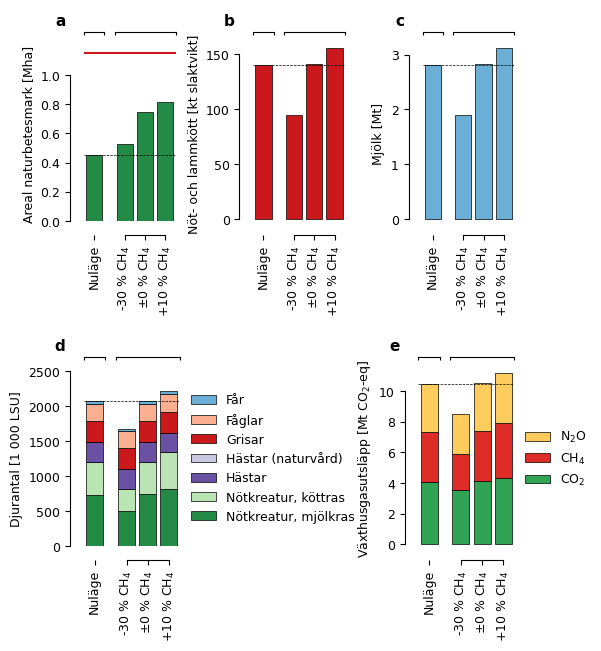

WIN_LAMB


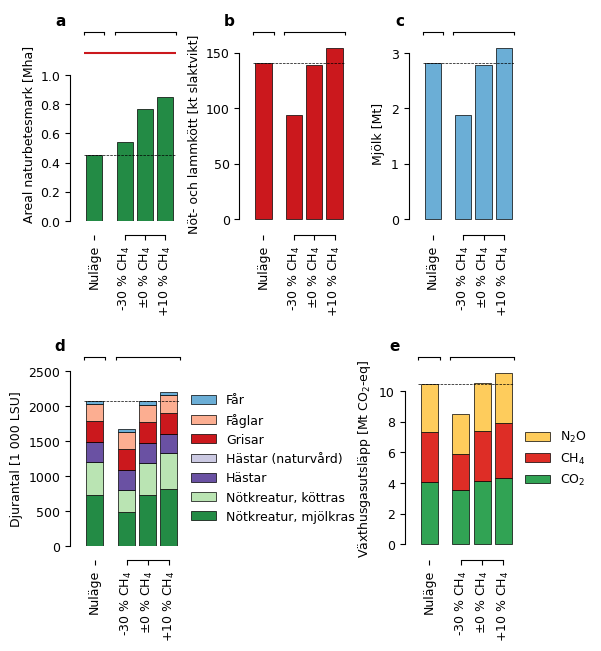

DRY_COWS


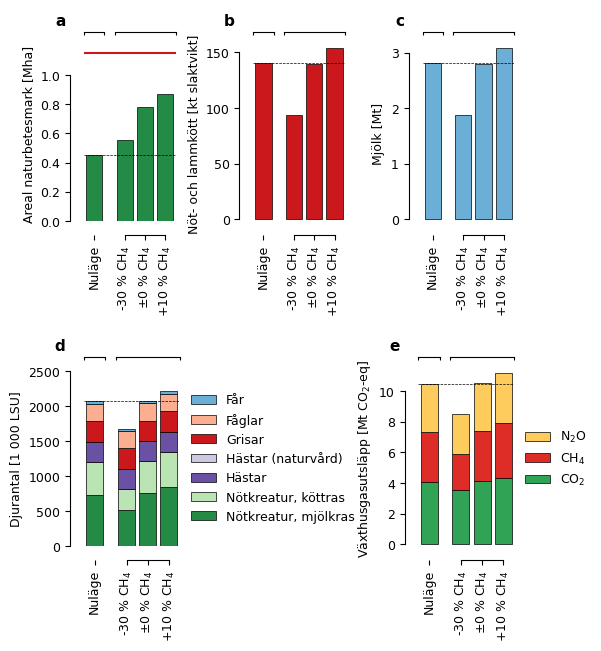

CUL_COWS


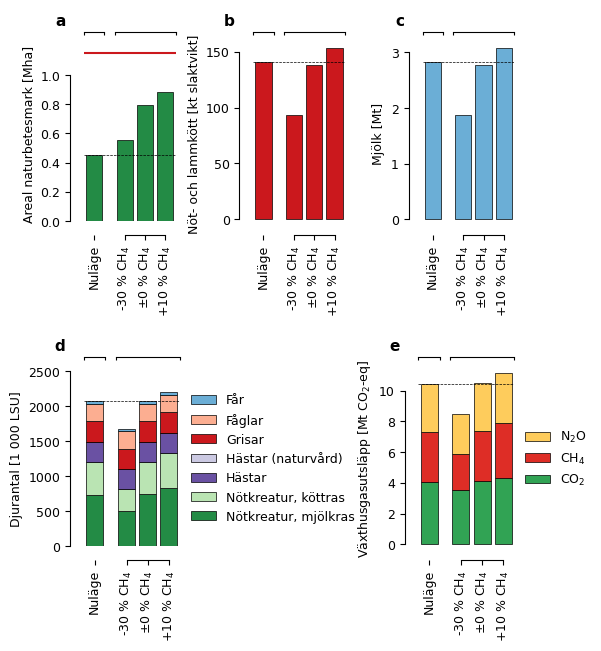

REC_HORSES


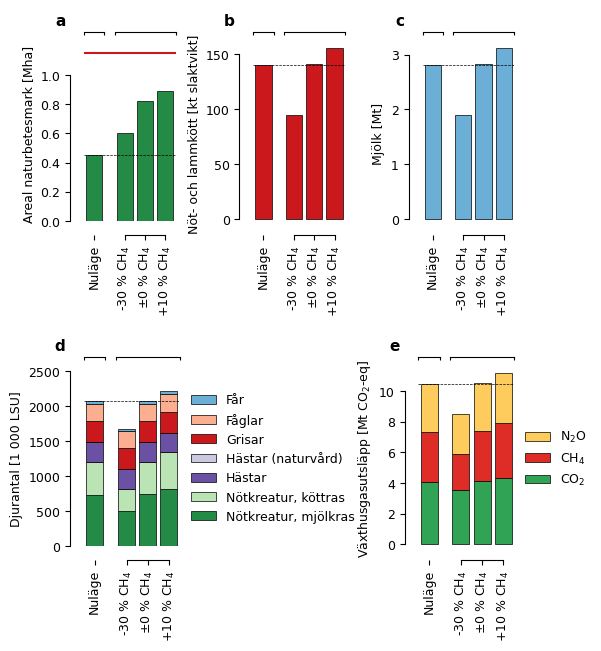

STEERS


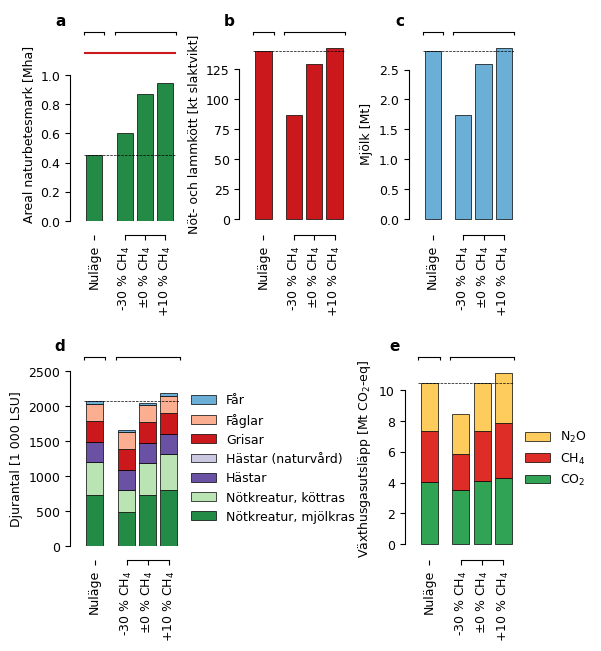

ALL


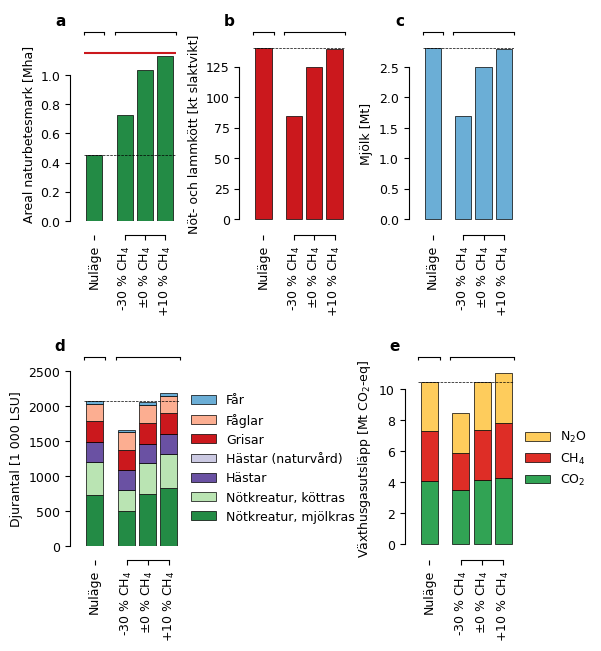

NAT_HORSES


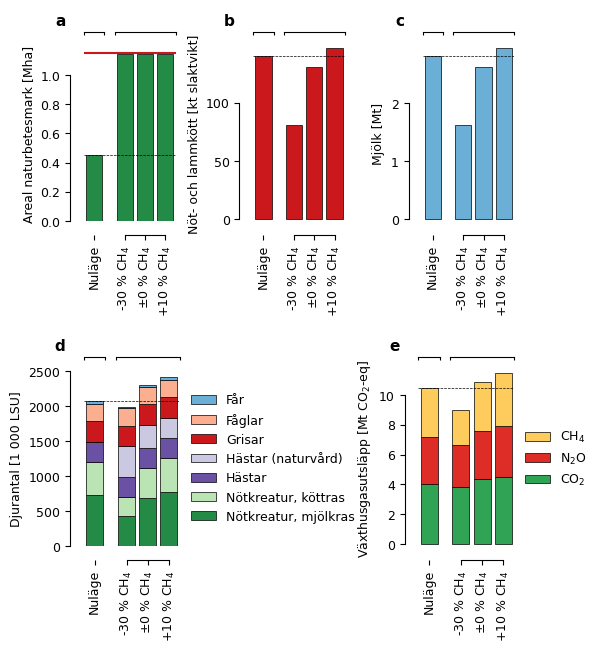

ALL + NAT_HORSES


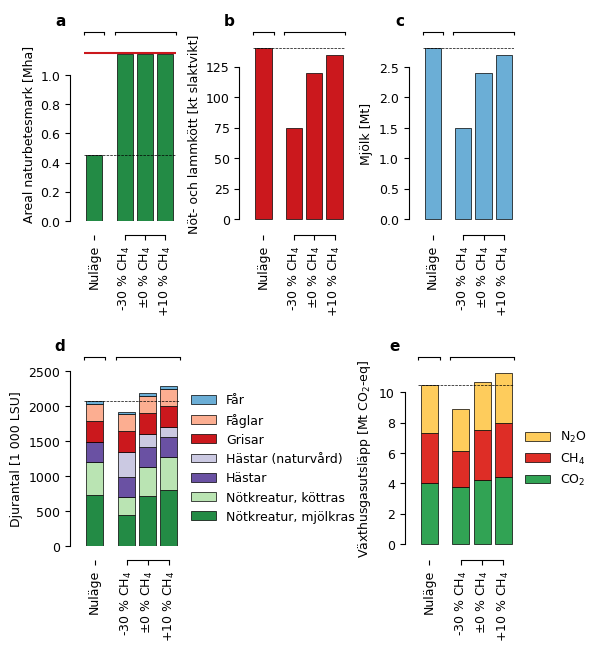

In [11]:
for scn in [s for s in sort if s != 'BL']:
    print(scn)
    fig = plt.figure(figsize = (4.3, 5))
    
    (topfig, bottomfig) = fig.subfigures(2, 1)
    
    top_axs = topfig.subplots(1, 3)
    bottom_axs = bottomfig.subplots(1, 2)
    
    ax = top_axs[0]
    cm.plot.bar(
        sng.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        group_levels='scn',
        ax=ax,
        cmap=ListedColormap(name='X', colors=['#238b45']),
        ylabel='Areal naturbetesmark [Mha]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9,
        ylim = (0,1.2)
    )
    ax.axhline(sng_bl, c='black', linewidth=0.5, linestyle='--')
    ax.axhline(sng_max, c='#cb181d', linewidth=1.5, linestyle='-')
    _legend_n(ax)
    _annotate(ax, 'a')
    
    ax = top_axs[1]
    cm.plot.bar(
        meat_milk.loc[['BL']+[scn],'meat'].rename(rename_scn_h, level='scn'),
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#cb181d']),
        ylabel='Nöt- och lammkött [kt slaktvikt]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(meat_milk_bl.loc['meat'], c='black', linewidth=0.5, linestyle='--')
    _legend_n(ax)
    _annotate(ax, 'b')
    
    ax = top_axs[2]
    cm.plot.bar(
        meat_milk.loc[['BL']+[scn],'milk'].rename(rename_scn_h, level='scn')/1000,
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#6baed6']),
        ylabel='Mjölk [Mt]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(meat_milk_bl.loc['milk']/1000, c='black', linewidth=0.5, linestyle='--')
    _legend_n(ax)
    _annotate(ax, 'c')
    
    
    ax = bottom_axs[0]
    cm.plot.bar(
        lsu.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        group_levels='scn',
        ax=ax,
        sort_xlabels=False,
        sort_groups=False,
        cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#cb181d', '#fcae91', '#6baed6']),
        ylabel='Djurantal [1 000 LSU]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9,
        ylim = (0,2500)
    )
    ax.axhline(lsu_bl, c='black', linewidth=0.5, linestyle='--')
    _legend_r(ax)
    _annotate(ax, 'd')
    
    ax = bottom_axs[1]
    cm.plot.bar(
        ghg.loc[['BL']+[scn]].rename(rename_scn_h, level='scn'),
        ax=ax,
        sort_categories=True,
        group_levels='scn',
        cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
        ylabel='Växthusgasutsläpp [Mt CO$_{2}$-eq]',
        ylabel_fontsize=9,
        grouplabels_fontsize=9,
        ticklabels_fontsize=9
    )
    ax.axhline(ghg_bl, c='black', linewidth=0.5, linestyle='--')
    _legend_r(ax)
    _annotate(ax, 'e')
    
    
    # Adjust plots
    topfig.subplots_adjust(left=0, right=1, bottom=0.3, top=1, wspace=0.85, hspace=0)
    bottomfig.subplots_adjust(left=0, right=1, bottom=0, top=0.7, wspace=2.5)
    
    plt.show()

## Maps

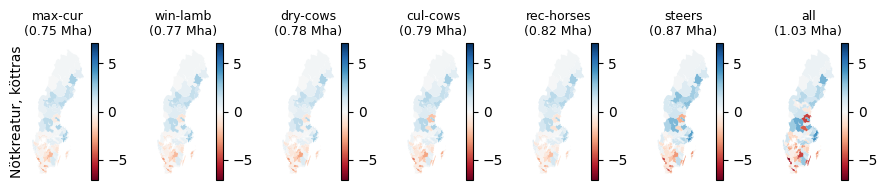

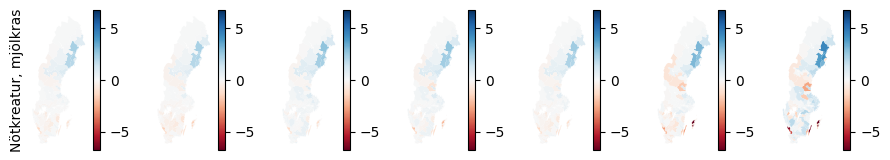

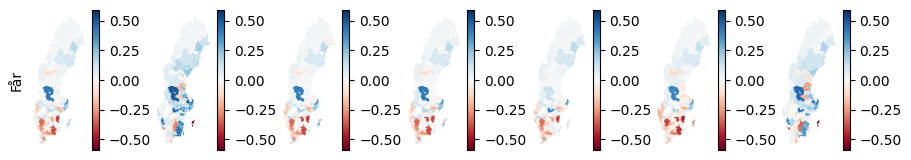

In [12]:
sps = ['Nötkreatur, köttras', 'Nötkreatur, mjölkras', 'Får']
scns = [s for s in sort if s not in ['BL','ALL + NAT_HORSES','NAT_HORSES']]

for sp in sps:
    _lsu_reg = lsu_reg.loc[:,sp]
    _lsu_reg = _lsu_reg.sub(_lsu_reg.loc[('BL', 'Nuläge')], axis=1).loc[scns]
    
    n = len(scns)
    
    fig, axs = plt.subplots(1,n, figsize=(1.3*n,2 if sp == sps[0] else 1.7))
    max = _lsu_reg.abs().max().quantile(0.95)
    
    for scn,ax in zip(scns, axs):
        cm.plot.map_from_series(
            _lsu_reg.loc[(scn, '$\pm$0 % CH$_{4}$')],
            ax = ax,
            cmap = 'RdBu',
            vmax = max,
            vmin = -max
        )
        no_axis(ax)
        if ax == axs[0]:
            ax.set_ylabel(sp)
        if sp == sps[0]:
            d = sng.loc[(scn,'$\pm$0 % CH$_{4}$')]
            ax.set_title(f"{rename_scn(scn)}\n({d:.2f} Mha)", size=9)
    
    # fig.suptitle(sp, size=11)
    plt.tight_layout()
    plt.show()

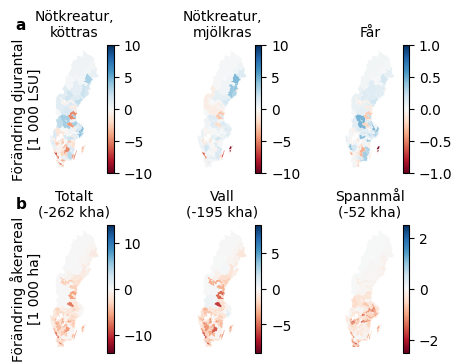

In [13]:
_lsu_reg = (lsu_reg.loc[('ALL', '$\pm$0 % CH$_{4}$')] - lsu_reg.loc[('BL', 'Nuläge')]) 

n = len(sps)
fig, axs = plt.subplots(2,n, figsize=(1.8*n,4), gridspec_kw = {'hspace':0.4})

for sp,ax in zip(sps, axs[0]):
    max = 10 * (0.1 if sp == 'Får' else 1)
    cm.plot.map_from_series(
        _lsu_reg.loc[sp],
        ax = ax,
        cmap = 'RdBu',
        vmin = -max,
        vmax = max
    )
    ax.set_title(sp.replace(', ',',\n'), size=10)
    no_axis(ax)
    if ax == axs[0][0]:
        ax.set_ylabel('Förändring djurantal\n[1 000 LSU]', size=10)

ax = axs[1][0]
d = cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-14,
    vmax=14
)
no_axis(ax)
ax.set_ylabel('Förändring åkerareal\n[1 000 ha]', size=10)
ax.set_title(f"Totalt\n({d.sum():.0f} kha)", size=10)

ax = axs[1][1]
d = ley.loc[('ALL','100')]-ley.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-9,
    vmax=9
)
no_axis(ax)
ax.set_title(f"Vall\n({d.sum():.0f} kha)", size=10)

ax = axs[1][2]
d = cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]
cm.plot.map_from_series(
    d,
    ax = ax,
    cmap='RdBu',
    vmin=-2.5,
    vmax=2.5
)
no_axis(ax)
ax.set_title(f"Spannmål\n({d.sum():.0f} kha)", size=10)

_annotate(axs[0][0], 'a  ')
_annotate(axs[1][0], 'b  ')

plt.show()

In [14]:
# Percentage change in crereals
(cereals.loc[('ALL','100')]-cereals.loc[('BL','0')]).sum() / cereals.loc[('BL','0')].sum() * 100

-6.067062862916388

In [15]:
# Percentage change in ley
(ley.loc[('ALL','100')]-ley.loc[('BL','0')]).sum() / ley.loc[('BL','0')].sum() * 100

-18.620499172043463

In [16]:
# Percentage change in total cropland
(cropland_tot.loc[('ALL','100')]-cropland_tot.loc[('BL','0')]).sum() / cropland_tot.loc[('BL','0')].sum() * 100

-11.111081945099963

In [17]:
grazing_per_lu

land_use,Naturbetesmark,Åkermark
scn,,
Nuläge,0.585471,0.833574
max-cur,0.979016,0.442748
win-lamb,1.007878,0.429704
dry-cows,1.027537,0.413026
cul-cows,1.039403,0.450968
rec-horses,1.081275,0.340535
steers,1.131296,0.480455
all,1.369374,0.336644
nat-horses,1.540349,0.490293


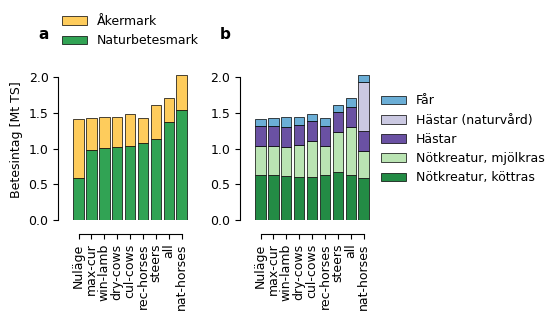

In [18]:
fig,axs = plt.subplots(1,2, figsize=(5.7,3.3))

ax = axs[0]
cm.plot.bar(
    grazing_per_lu,
    ax = ax,
    cmap=ListedColormap(name='X', colors=['#31a354', '#fecc5c']),
    ylabel='Betesintag [Mt TS]',
    ylabel_fontsize=9,
    ticklabels_fontsize=9,
    ylim=(0,2.26)
)
_legend_t(ax, 1, cols=1)
_annotate(ax, 'a')

ax = axs[1]

cm.plot.bar(
    grazing_per_species,
    ax = ax,
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#6baed6']),
    ylabel_fontsize=9,
    ticklabels_fontsize=9,
    ylim=(0,2.26)
)
# _legend_t(ax, 1.15, cols=1)
_legend_r(ax)
_annotate(ax, 'b')

plt.tight_layout()
plt.show()

In [19]:
grazing_per_lu.sub(grazing_per_lu.loc['Nuläge'], axis=1)


land_use,Naturbetesmark,Åkermark
scn,,
Nuläge,0.000000,0.000000
max-cur,0.393545,-0.390826
win-lamb,0.422407,-0.403870
dry-cows,0.442066,-0.420548
cul-cows,0.453932,-0.382605
rec-horses,0.495804,-0.493039
steers,0.545825,-0.353119
all,0.783903,-0.496930
nat-horses,0.954877,-0.343280


In [20]:
grazing_per_lu.sub(grazing_per_lu.loc['max-cur'], axis=1)*1000

land_use,Naturbetesmark,Åkermark
scn,,
Nuläge,-393.544700,390.826179
max-cur,0.000000,0.000000
win-lamb,28.862627,-13.043596
dry-cows,48.520994,-29.721458
cul-cows,60.387649,8.220802
rec-horses,102.258987,-102.212566
steers,152.280667,37.707603
all,390.358460,-106.103652
nat-horses,561.332792,47.545768


(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

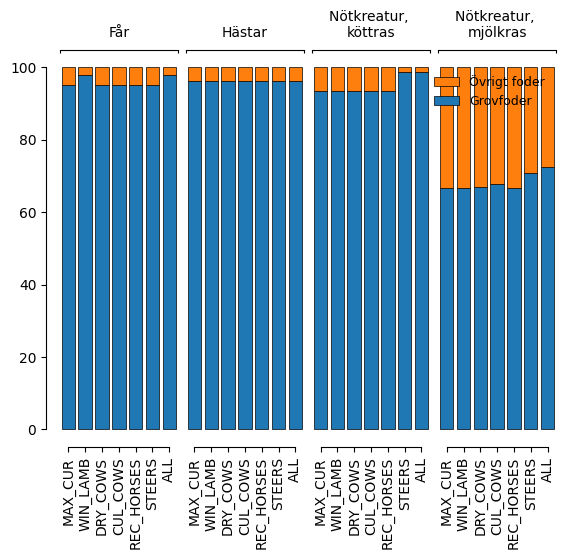

In [21]:
def rename_feeds(x):
    if x in ['ley silage, 1st cut',
             'ley silage, regrowth',
             'other silage',
             'hay',
             'maize silage',
             'grazing']:
        return 'Grovfoder'
    else:
        return 'Övrigt foder'

d = (
    session.get_attr('a','feed.consumption',['species','breed','feed'])
    .rename(columns=rename_feeds, level='feed')
    .rename(rename_years)
    .T.groupby(['species','breed','feed']).sum().T
    .loc[(scns,['Nuläge','$\pm$0 % CH$_{4}$']),:]
    .droplevel('year')
)

d.columns = pd.MultiIndex.from_tuples(
    [(f'{sp}, {br}', fe) if sp == 'cattle'
     else (sp, fe)
     for sp,br,fe in d.columns],
    names = ['species','feed']
)

d = d.T.groupby(['species','feed']).sum().T

d = d.T.groupby('species').apply(lambda x: x/x.sum() * 100).droplevel(0).T

d = (
    d
    .rename({
        'cattle, dairy' : 'Nötkreatur, mjölkras',
        'cattle, beef' : 'Nötkreatur, köttras',
        'sheep' : 'Får',
        'horses' : 'Hästar',
        'horses, cons.' : 'Hästar (naturvård)',
        'poultry' : 'Fåglar',
        'pigs' : 'Grisar'
    }, axis=1)
)

d = d.drop(['Grisar','Fåglar'], axis=1, level='species')

d = d.stack('species')

cm.plot.bar(
    d,
    group_levels='species'
)

## Numbers for text

In [22]:
sng_bl = ((sng - sng.loc['BL','Nuläge']) / sng.loc['BL','Nuläge'] * 100).drop('BL')
sng2 = sng.drop('BL').unstack()
sng2_bl = sng_bl.unstack()

sng2 = sng2.sub(sng2.loc['MAX_CUR'], axis=1).div(sng2.loc['MAX_CUR'], axis=1) * 100
sng2_bl = sng2_bl.sub(sng2_bl.loc['MAX_CUR'], axis=1)

C:\Users\jnka0003\AppData\Local\Temp\ipykernel_24184\3849719219.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sng_bl = ((sng - sng.loc['BL','Nuläge']) / sng.loc['BL','Nuläge'] * 100).drop('BL')
C:\Users\jnka0003\AppData\Local\Temp\ipykernel_24184\3849719219.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  sng2 = sng.drop('BL').unstack()


In [23]:
# Total area semi-natural grasslands
sng.unstack()

year,$\pm$0 % CH$_{4}$,+10 % CH$_{4}$,-30 % CH$_{4}$,Nuläge
scn,,,,
ALL,1.031911,1.128397,0.727678,NaN
ALL + NAT_HORSES,1.146048,1.146048,1.146048,NaN
BL,NaN,NaN,NaN,0.453674
CUL_COWS,0.794068,0.882968,0.556815,NaN
DRY_COWS,0.783160,0.873940,0.553746,NaN
MAX_CUR,0.749066,0.816966,0.528722,NaN
NAT_HORSES,1.145226,1.145226,1.145226,NaN
REC_HORSES,0.822239,0.892830,0.601534,NaN
STEERS,0.867775,0.948171,0.601228,NaN


In [24]:
# Percentage change in semi-natural grassalnd area from baseline
sng_bl.unstack()

year,-30 % CH$_{4}$,$\pm$0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,16.542143,65.110956,80.077524
STEERS,32.524123,91.277013,108.998027
REC_HORSES,32.591480,81.239803,96.799615
WIN_LAMB,19.690283,69.670584,87.086500
CUL_COWS,22.734424,75.030474,94.625824
DRY_COWS,22.058118,72.625914,92.635912
ALL,60.396622,127.456381,148.723897
ALL + NAT_HORSES,152.614667,152.614667,152.614667
NAT_HORSES,152.433501,152.433501,152.433501


In [26]:
# Difference in percentage change from baseline between scenario and MAX_CUR scenario
sng2_bl

year,-30 % CH$_{4}$,$\pm$0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,0.000000,0.000000,0.000000
STEERS,15.981980,26.166057,28.920503
REC_HORSES,16.049337,16.128847,16.722091
WIN_LAMB,3.148140,4.559628,7.008976
CUL_COWS,6.192281,9.919518,14.548301
DRY_COWS,5.515976,7.514958,12.558389
ALL,43.854479,62.345425,68.646373
ALL + NAT_HORSES,136.072524,87.503711,72.537143
NAT_HORSES,135.891358,87.322545,72.355977


In [25]:
# Percentage change in semi-natural grassland area from MAX_CUR scenario
sng2

year,-30 % CH$_{4}$,$\pm$0 % CH$_{4}$,+10 % CH$_{4}$
scn,,,
MAX_CUR,0.000000,0.000000,0.000000
STEERS,13.713477,15.847559,16.060029
REC_HORSES,13.771273,9.768490,9.286051
WIN_LAMB,2.701289,2.761554,3.892199
CUL_COWS,5.313340,6.007789,8.078910
DRY_COWS,4.733031,4.551459,6.973879
ALL,37.629717,37.759714,38.120456
ALL + NAT_HORSES,116.758213,52.996913,40.281064
NAT_HORSES,116.602762,52.887190,40.180460
